# VDM for generative modeling

The notebook implements the **Variational Diffusion Model (VDM)** — a special case of the SDE notebook with three substitutions:

1. The variational distribution uses a **fixed VP scalar schedule** instead of learned networks: $\alpha(y,t)=a_t\,y$ and $\beta(y,t)=b_t$, derived from a linear log-SNR schedule with two learnable endpoints.
2. The diffusion coefficient $\sigma(x,t)=\sigma(t)$ is fixed by the schedule. For the generative (noise$\to$data) SDE the coefficient is $\tilde\sigma^2(t)=-a_t^2\,\frac{d}{dt}[b_t^2/a_t^2]=({\log\mathrm{SNR}_1-\log\mathrm{SNR}_0})\,b_t^2>0$.
3. The drift is set to $f(x,t)=g(x,\widehat{y}(x,t),t)$, where $\widehat{y}(x_t,t)$ is a learned **signal prediction network**.

With these substitutions the ELBO drift-matching term $(f-g)^2/(2\tilde\sigma^2)$ reduces exactly to an SNR-weighted prediction loss, giving:
$$
\log p(y)\;\ge\;
\underbrace{\mathbb{E}_{q_1}[\log p(y|x_1)]}_{\text{likelihood}}
-\underbrace{\mathrm{KL}(q_0\|p_0)}_{=\,0}
-\frac{1}{2}\int_0^1 \frac{d\,\mathrm{SNR}(t)}{dt}\,\mathbb{E}_{q_t}\!\left[(y-\widehat{y}(x_t,t))^2\right]dt.
$$

Convention: $t=0$ is the noise prior $p_0=\mathcal{N}(0,1)$, $t=1$ is the data — matching notebooks 01–03.


## Setup

In [80]:
import os, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    os.system("wget -q https://raw.githubusercontent.com/olewinther/generative-ode-sde/main/utils.py")
else:
    for path in ['..', '.']:
        if os.path.exists(os.path.join(path, 'utils.py')):
            sys.path.insert(0, os.path.abspath(path))
            break

from utils import *

## GPU

In [81]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('GPU State:', device)

GPU State: cpu


## Network components

Replacing the SDE notebook's learned `AlphaNetwork`, `BetaNetwork`, `DiffusionNetwork`, and `DriftNetwork` with their VDM counterparts:

- **SNRSchedule**: derives $a(t)$, $b(t)$, $\sigma(t)$ from $\log\mathrm{SNR}(t)=(1-t)\log\mathrm{SNR}(0)+t\,\log\mathrm{SNR}(1)$ and VP.
- **SignalPredictionNetwork** $\widehat{y}(x_t,t)$: replaces the drift network.
- **VDMDrift** / **VDMBackwardDrift** / **VDMSigma**: wrap the schedule and $\widehat{y}$ into the callables expected by `ForwardPath` / `BackwardPath`.

In [82]:
import torch.nn as nn


class SNRSchedule(nn.Module):
    """Linear log-SNR schedule with variance preservation."""
    def __init__(self, log_snr_0=-10.0, log_snr_1=10.0, trainable=False):
        super().__init__()
        for name, val in [('log_snr_0', log_snr_0), ('log_snr_1', log_snr_1)]:
            buf = torch.tensor(float(val))
            if trainable:
                setattr(self, name, nn.Parameter(buf))
            else:
                self.register_buffer(name, buf)

    def log_snr(self, t): return (1 - t) * self.log_snr_0 + t * self.log_snr_1
    def snr(self, t):     return torch.exp(self.log_snr(t))
    def a(self, t):       return torch.sqrt(self.snr(t) / (1 + self.snr(t)))
    def b(self, t):       return torch.sqrt(1 / (1 + self.snr(t)))

    def sigma_sq(self, t):
        # Diffusion coefficient of the generative (noise→data) SDE.
        # = −a²·d/dt[b²/a²] = (log_snr_1 − log_snr_0)·b²  [> 0]
        return (self.log_snr_1 - self.log_snr_0) * self.b(t) ** 2


class VDMAlpha(nn.Module):
    """alpha_net(y, t) = a(t)·y  — the variational mean, matching the SDE notebook convention."""
    def __init__(self, schedule):
        super().__init__()
        self.schedule = schedule

    def forward(self, y, t):
        return self.schedule.a(t) * y

    def d_dt(self, y, t):
        s = self.schedule
        return s.a(t) * s.sigma_sq(t) / 2 * y


class VDMBeta(nn.Module):
    """beta_net(y, t) = b(t)  — the variational std, matching the SDE notebook convention."""
    def __init__(self, schedule):
        super().__init__()
        self.schedule = schedule

    def forward(self, y, t):
        return self.schedule.b(t).expand_as(y)

    def d_dt(self, y, t):
        s = self.schedule
        return (-s.a(t) ** 2 * s.sigma_sq(t) / (2 * s.b(t))).expand_as(y)


class VDMSigma(nn.Module):
    """sigma(x, t) = sqrt(sigma_sq(t)) > 0;  d_sq_dx = 0 (x-independent)"""
    def __init__(self, schedule):
        super().__init__()
        self.schedule = schedule

    def forward(self, x, t):
        return torch.sqrt(self.schedule.sigma_sq(t)).expand_as(x)

    def d_sq_dx(self, x, t):
        return torch.zeros_like(x)


class SignalPredictionNetwork(nn.Module):
    """Predicts y from noisy x_t and time t.
    Skip connection yhat = x + net(x,t) so the untrained network starts near yhat≈x_t.
    At high SNR x_t≈y, giving O(b²) initial prediction error instead of O(1)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x, t):
        return x + self.net(torch.cat([x, t], dim=-1))


class VDMDrift(nn.Module):
    """f(x,t) = g(x, yhat(x,t), t) for use in ForwardPath (generation)."""
    def __init__(self, yhat_net, schedule):
        super().__init__()
        self.yhat_net = yhat_net
        self.schedule = schedule

    def forward(self, x, t):
        yhat = self.yhat_net(x, t)
        s    = self.schedule
        a, b = s.a(t), s.b(t)
        sigma_sq = s.sigma_sq(t)
        d_a  = a * sigma_sq / 2
        d_b  = -a ** 2 * sigma_sq / (2 * b)
        score = -(x - a * yhat) / b ** 2
        return d_a * yhat + d_b * (x - a * yhat) / b + (sigma_sq / 2) * score


class VDMBackwardDrift(nn.Module):
    """Backward ODE drift for encoding (no sigma correction)."""
    def __init__(self, yhat_net, schedule):
        super().__init__()
        self.yhat_net = yhat_net
        self.schedule = schedule

    def forward(self, x, t):
        yhat = self.yhat_net(x, t)
        s    = self.schedule
        a, b = s.a(t), s.b(t)
        sigma_sq = s.sigma_sq(t)
        d_a = a * sigma_sq / 2
        d_b = -a ** 2 * sigma_sq / (2 * b)
        return d_a * yhat + d_b * (x - a * yhat) / b


class ScheduleBeta(nn.Module):
    """Likelihood width tied to schedule.b(1), mirroring BetaNetwork(beta=beta) in the SDE notebook."""
    def __init__(self, schedule):
        super().__init__()
        self.schedule = schedule

    def forward(self):
        return self.schedule.b(torch.ones(1))


class Likelihood(nn.Module):
    def __init__(self, beta):
        super().__init__()
        self.beta = beta

    def log_prob(self, y, x):
        var = self.beta() ** 2
        return -0.5 * ((y - x) ** 2 / var + torch.log(2 * torch.pi * var))

    def sample(self, x):
        return x + torch.randn_like(x) * self.beta()


## Visualize schedule and learned signal prediction

In [83]:
def plot_schedule(schedule, num_samples=3):
    t_grid    = torch.linspace(0, 1, 200).unsqueeze(1)
    y_samples = torch.randn(num_samples, 1)
    with torch.no_grad():
        b_vals     = [schedule.b(t).item() for t in t_grid]
        sigma_vals = [torch.sqrt(schedule.sigma_sq(t)).item() for t in t_grid]

    fig, axes = plt.subplots(3, 1, figsize=(10, 9))
    for y in y_samples:
        with torch.no_grad():
            alpha_vals = [schedule.a(t).item() * y.item() for t in t_grid]
        axes[0].plot(t_grid.numpy(), alpha_vals, label=f"y={y.item():.2f}")
    axes[0].set_title(r"$\alpha(y,t)$"); axes[0].set_xlabel("t"); axes[0].set_ylabel(r"$\alpha(y,t)$"); axes[0].legend()
    axes[1].plot(t_grid.numpy(), b_vals)
    axes[1].set_title(r"$\beta(t)$"); axes[1].set_xlabel("t"); axes[1].set_ylabel(r"$\beta(t)$")
    axes[2].plot(t_grid.numpy(), sigma_vals)
    axes[2].set_title(r"$\sigma(t)$"); axes[2].set_xlabel("t"); axes[2].set_ylabel(r"$\sigma(t)$")
    plt.tight_layout(); plt.show()


def plot_yhat(yhat_net, schedule, num_samples=3):
    t_grid    = torch.linspace(0, 1, 100).unsqueeze(1)
    x_samples = torch.randn(num_samples, 1)

    fig, ax = plt.subplots(figsize=(10, 3))
    for s in x_samples:
        with torch.no_grad():
            vals = [yhat_net(s, t.expand_as(s)).item() for t in t_grid]
        ax.plot(t_grid.numpy(), vals, label=f"x={s.item():.2f}")
    ax.set_title(r"$\widehat{y}(x,t)$"); ax.set_xlabel("t"); ax.set_ylabel(r"$\widehat{y}$"); ax.legend()
    plt.tight_layout(); plt.show()

## VDM ELBO and training loop

In [84]:
def compute_elbo_vdm(yhat_net, vdm_alpha, vdm_beta, vdm_sigma, prior, likelihood, y, t_sample):
    # 1. Likelihood term
    q_x1 = Variational(vdm_alpha, vdm_beta, y, torch.full(y.size(), 1.0))
    x_1 = q_x1.sample()
    likelihood_term = likelihood.log_prob(y, x_1)

    # 2. KL divergence term
    q_x0 = Variational(vdm_alpha, vdm_beta, y, torch.full(y.size(), 0.0))
    x_0 = q_x0.sample()
    kl_divergence = q_x0.log_prob(x_0) - prior.log_prob(x_0)

    # 3. Drift matching term
    q_xt = Variational(vdm_alpha, vdm_beta, y, t_sample)
    x_t = q_xt.sample()
    yhat = yhat_net(x_t, t_sample)
    f_xt, _ = Variational(vdm_alpha, vdm_beta, yhat, t_sample).drift(x_t, mode="sde", sigma_net=vdm_sigma)
    g_xt, _ = q_xt.drift(x_t, mode="sde", sigma_net=vdm_sigma)
    sigma_squared = vdm_sigma(x_t, t_sample) ** 2
    drift_matching_term = 0.5 * (f_xt - g_xt) ** 2 / sigma_squared

    elbo = likelihood_term - kl_divergence - drift_matching_term
    return elbo.mean(), likelihood_term.mean(), kl_divergence.mean(), drift_matching_term.mean()


def training_loop_vdm(yhat_net, vdm_alpha, vdm_beta, vdm_sigma, prior, likelihood,
                      data_loader, validation_set, n_epochs=1000, lr=1e-3, max_grad_norm=1.0,
                      schedule=None):
    from collections import deque
    optimizer = torch.optim.Adam(
        list(yhat_net.parameters()) + list(likelihood.beta.parameters()), lr=lr)
    train_history, val_history = deque(maxlen=5), deque(maxlen=5)
    for epoch in range(n_epochs):
        total_elbo = 0.0
        for y_batch in data_loader:
            optimizer.zero_grad()
            t_sample = torch.rand(y_batch.size())
            elbo, *_ = compute_elbo_vdm(
                yhat_net, vdm_alpha, vdm_beta, vdm_sigma, prior, likelihood, y_batch, t_sample)
            total_elbo += elbo.item()
            (-elbo).backward()
            torch.nn.utils.clip_grad_norm_(
                list(yhat_net.parameters()) + list(likelihood.beta.parameters()), max_grad_norm)
            optimizer.step()
        if epoch % 50 == 0 or epoch == n_epochs - 1:
            t_val = torch.rand(validation_set.size())
            elbo_val, ll, kl, dm = compute_elbo_vdm(
                yhat_net, vdm_alpha, vdm_beta, vdm_sigma, prior, likelihood, validation_set, t_val)
            train_cur = total_elbo / len(data_loader)
            val_cur = elbo_val.item()
            train_history.append(train_cur)
            val_history.append(val_cur)
            avg_train = sum(train_history) / len(train_history)
            avg_val   = sum(val_history)   / len(val_history)
            schedule_str = ""
            if schedule is not None:
                schedule_str = (f" | log_snr=({schedule.log_snr_0.item():.2f}, "
                                f"{schedule.log_snr_1.item():.2f})")
            print(f"Epoch {epoch:4d} | train {train_cur:.4f} (avg {avg_train:.4f}) | "
                  f"val {val_cur:.4f} (avg {avg_val:.4f}) | "
                  f"ll={ll:.4f}, kl={kl:.4f}, dm={dm:.4f}{schedule_str}")
    return yhat_net


## Create training and validation data

In [85]:
torch.manual_seed(42)
np.random.seed(42)

n_samples, n_val = 1000, 8000

# Choose distribution: 'gaussian', 'laplace', 'laplace_mixture'
training_set_dist = 'laplace_mixture'

if training_set_dist == 'gaussian':
    params = {'mean': torch.tensor(-1.0), 'std': torch.tensor(2.0)}
elif training_set_dist == 'laplace':
    params = {'loc': torch.tensor(0.0), 'scale': torch.tensor(1.0)}
elif training_set_dist == 'laplace_mixture':
    params = {'k': 5, 'spacing': 4.0, 'scale': torch.tensor(1.0)}

training_set = TrainingSetWithLogLikelihood(training_set_dist, params)
training_data, ell_train = training_set.generate_training_data(n_samples)
validation_data, ell_val = training_set.generate_training_data(n_val)
print(f"{training_set_dist} | true log-likelihood: train={ell_train:.4f}, val={ell_val:.4f}")

laplace_mixture | true log-likelihood: train=-2.9829, val=-2.9862


## Run training

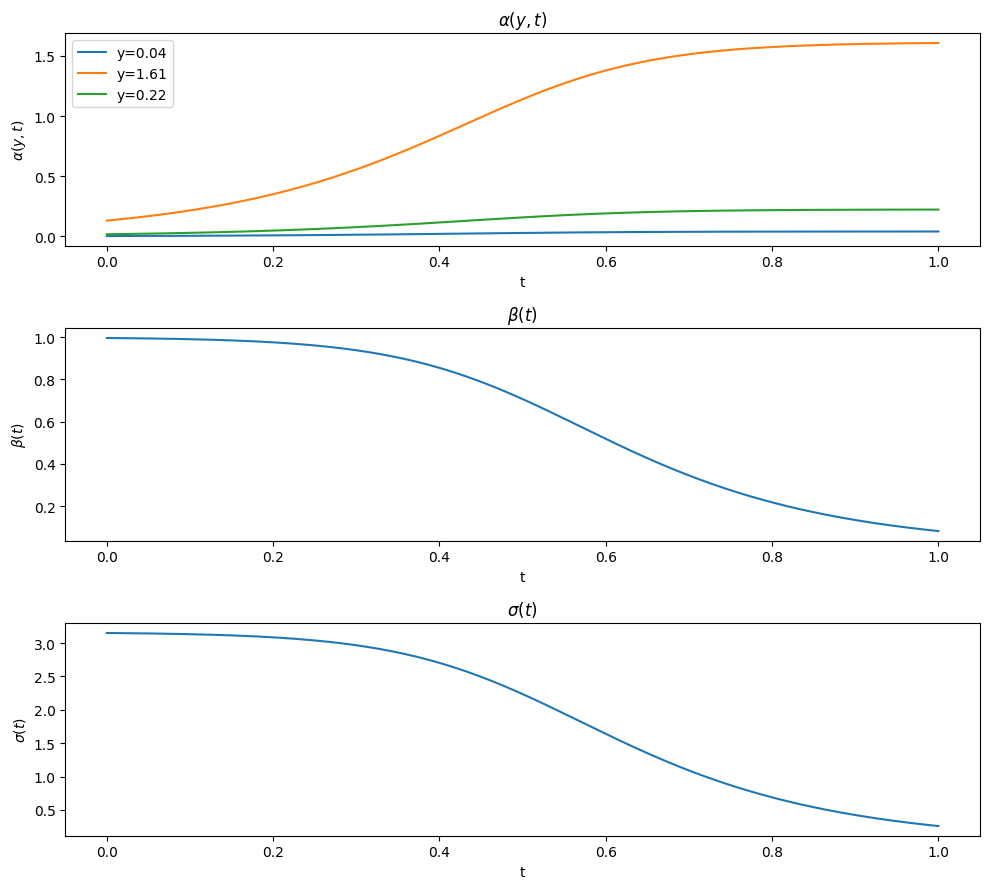

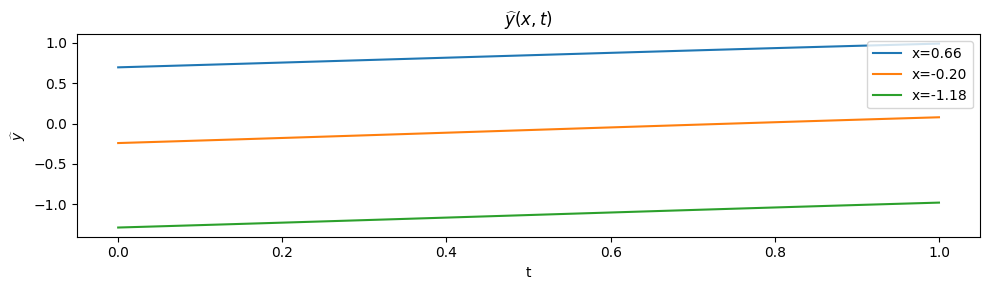

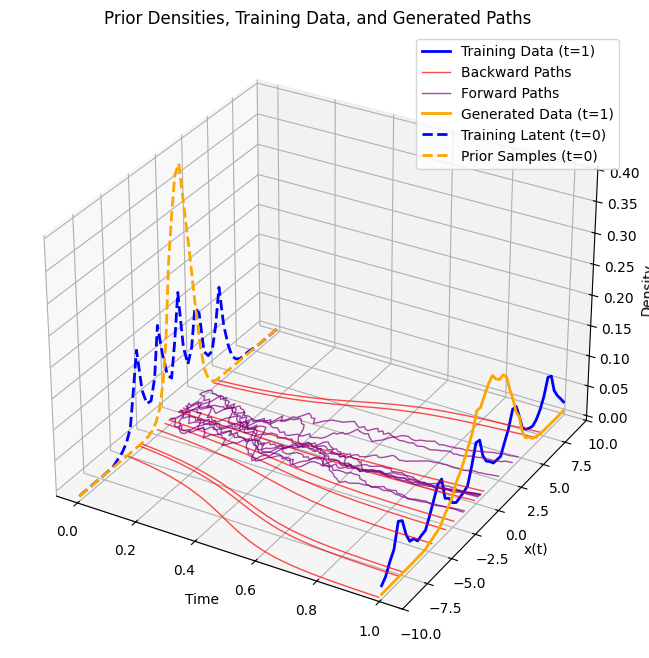

Epoch    0 | train -8.1964 (avg -8.1964) | val -7.4235 (avg -7.4235) | ll=1.0534, kl=0.1077, dm=8.3692 | log_snr=(-5.00, 4.99)
Epoch   50 | train -7.1995 (avg -7.6979) | val -6.0317 (avg -6.7276) | ll=0.9398, kl=0.1120, dm=6.8594 | log_snr=(-5.00, 4.77)
Epoch  100 | train -5.0625 (avg -6.8195) | val -4.8483 (avg -6.1012) | ll=0.8610, kl=0.1210, dm=5.5883 | log_snr=(-4.94, 4.62)
Epoch  150 | train -4.2970 (avg -6.1889) | val -4.5071 (avg -5.7026) | ll=0.7276, kl=0.1212, dm=5.1135 | log_snr=(-4.92, 4.39)
Epoch  200 | train -4.6486 (avg -5.8808) | val -4.4656 (avg -5.4552) | ll=0.5615, kl=0.1172, dm=4.9099 | log_snr=(-4.91, 4.12)
Epoch  250 | train -4.2790 (avg -5.0973) | val -4.2997 (avg -4.8305) | ll=0.4278, kl=0.1338, dm=4.5937 | log_snr=(-4.86, 3.84)
Epoch  300 | train -4.0523 (avg -4.4679) | val -3.6448 (avg -4.3531) | ll=0.2775, kl=0.1395, dm=3.7828 | log_snr=(-4.80, 3.59)
Epoch  350 | train -3.5944 (avg -4.1743) | val -3.6955 (avg -4.1225) | ll=0.1477, kl=0.1449, dm=3.6983 | log_sn

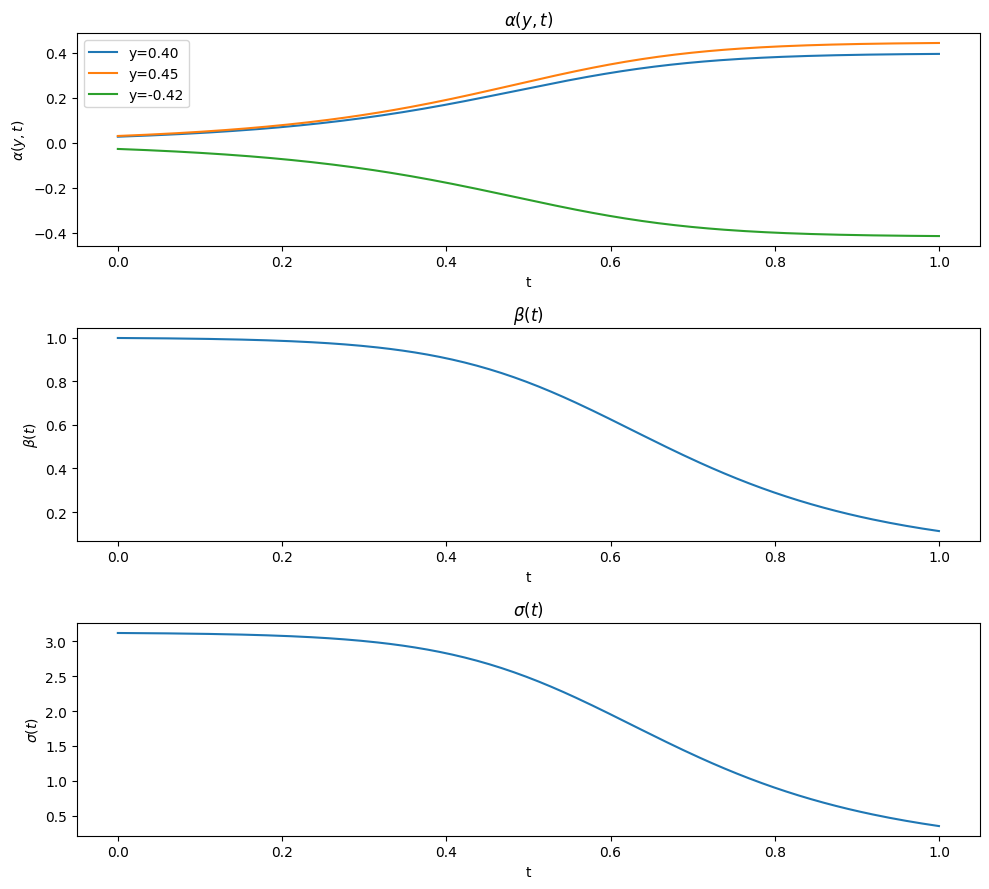

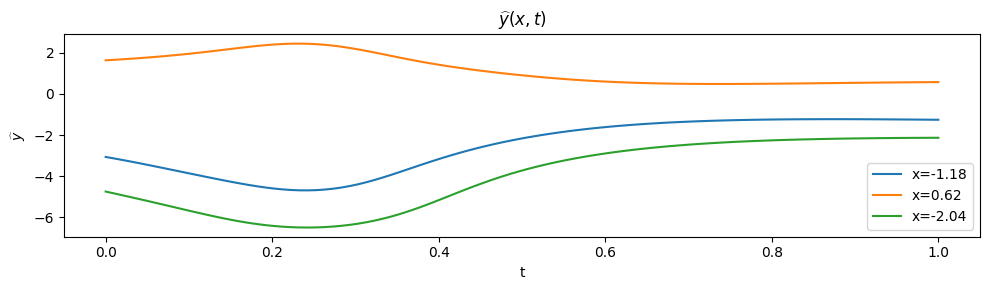

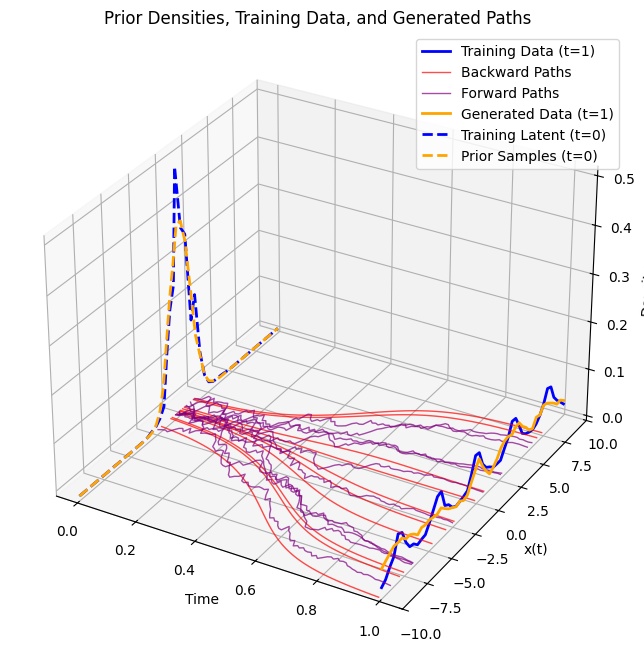

In [86]:
data_loader = torch.utils.data.DataLoader(training_data, batch_size=125, shuffle=True)

schedule  = SNRSchedule(log_snr_0=-5.0, log_snr_1=5.0, trainable=True)
yhat_net  = SignalPredictionNetwork()
vdm_alpha = VDMAlpha(schedule)
vdm_beta  = VDMBeta(schedule)
vdm_sigma = VDMSigma(schedule)

prior      = Prior(gaussian_sample, gaussian_log_pdf)
likelihood = Likelihood(beta=ScheduleBeta(schedule))

t = torch.linspace(0, 1, steps=100)

f_net     = VDMDrift(yhat_net, schedule)
f_net_bwd = VDMBackwardDrift(yhat_net, schedule)

forward_path = ForwardPath(mode="sde", f_net=f_net, sigma_net=vdm_sigma, prior=prior)

# ODE (deterministic encoding) or backward SDE (stochastic encoding) — pick one:
backward_path = BackwardPath(mode="ode", f_net=f_net_bwd)
# backward_path = BackwardPath(mode="backward sde", alpha_net=vdm_alpha, beta_net=vdm_beta, sigma_net=vdm_sigma)

plot_schedule(schedule)
plot_yhat(yhat_net, schedule)
visualize_paths_and_marginals(validation_data, t, backward_path, forward_path)

yhat_net = training_loop_vdm(
    yhat_net, vdm_alpha, vdm_beta, vdm_sigma, prior, likelihood,
    data_loader, validation_data, n_epochs=2000, lr=1e-3,
    schedule=schedule,
)

plot_schedule(schedule)
plot_yhat(yhat_net, schedule)
visualize_paths_and_marginals(validation_data, t, backward_path, forward_path)
